# DeepSVDD v3 — 聚类策略对比

**Exp A**: 参数聚类 — 按 teff/logg/feh 聚类，簇内 KNN 计算差分特征

**Exp B**: 掩带聚类 — 掩盖 CN3839/CN4142/CH4300 分子带后 PCA 聚类，簇内 KNN 计算差分

两者共享全光谱数据，对比不同聚类策略下 12-D 物理特征的 DeepSVDD 效果。
候选光谱可视化使用**聚类平均**光谱作为参考（而非全局平均）。

In [3]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import warnings
warnings.filterwarnings('ignore')

_root = os.path.dirname(os.getcwd()) if 'Deep' in os.getcwd() else os.getcwd()
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

from Deep.config import DeepSVDDConfig
from Deep.data import (
    load_spectra_data,
    compute_physics_features_param_cluster,
    compute_physics_features_masked_cluster,
)
from Deep.models import DeepSVDD
from Deep.train import DeepSVDDTrainer
from Deep.evaluate import evaluate_model, summarize_results, select_candidates

print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')

PyTorch: 2.5.1+cu121, CUDA: True


In [4]:
# 加载全光谱数据（两个实验共享）
dataset_full = load_spectra_data(verbose=True)

Loading LAMOST spectra (segment normalisation)


100%|██████████| 48440/48440 [09:21<00:00, 86.27it/s] 



Pipeline summary:
  n_input: 48440
  n_after_dropna: 48440
  n_positive_labeled: 108
  n_loaded: 37086
  n_normalized_ok: 37086
  n_after_uid_dedup: 34123
  n_after_anomaly_filter: 33512
  n_positive (final): 73
  n_unlabeled (final): 33439
  Spectra shape: (33512, 5180)


---
## Experiment A: 参数聚类（teff / logg / feh）

用恒星物理参数做 KMeans 聚类，簇内 KNN 在物理参数空间搜索邻居，
计算差分特征 delta = CN_index - neighbor_median(CN_index)。
这样差分特征反映的是**同类物理参数恒星中**的 CN 增强程度。

In [5]:
print('Computing param-cluster features...')
result_a = compute_physics_features_param_cluster(dataset_full, random_seed=42)
dataset_a = result_a['dataset']
cluster_labels_a = result_a['cluster_labels']
cluster_mean_a = result_a['cluster_mean_spectra']
print(f'  Features: {dataset_a.X.shape}')
print(f'  Clusters: {result_a["n_clusters"]}')

Computing param-cluster features...
  Param-cluster: 45 clusters (teff/logg/feh)
  Features: (33512, 12)
  Clusters: 45


In [6]:
# Exp A 训练
print('='*60)
print('EXP A: Param Cluster (teff/logg/feh)')
print('='*60)

config_a = DeepSVDDConfig(
    input_dim=dataset_a.n_features,
    hidden_dims=[64, 32],
    latent_dim=8,
    encoder_type='mlp',
    objective='soft-boundary',
    nu=0.05,
    learning_rate=1e-3,
    batch_size=256,
    n_epochs=200,
    early_stopping_patience=40,
    clean_cn_percentile=95.0,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)
print(f'Input: {config_a.input_dim} features')

trainer_a = DeepSVDDTrainer(config_a, save_dir='Deep/checkpoints/v3_param')
model_a = trainer_a.train(dataset_a, verbose=True)

metrics_a = evaluate_model(model_a, dataset_a, device=config_a.device)
print(summarize_results(metrics_a))

EXP A: Param Cluster (teff/logg/feh)
Input: 12 features
CN pre-clean: threshold=0.0000, removed 0 unlabeled (0.0%), known-CN median=0.0000
  Train samples (clean): 30,096 / 33,439 unlabeled
Model: 3,073 parameters
  Input: 12
  Hidden: [64, 32]
  Latent: 8
  Encoder: mlp
  Objective: soft-boundary
Initializing hypersphere center...

Training for up to 200 epochs...
  Train samples: 30096
------------------------------------------------------------
Epoch  10/200 | loss: 0.0489 | val_loss: 0.0400 | lr: 1.00e-03
Epoch  20/200 | loss: 0.0352 | val_loss: 0.0270 | lr: 1.00e-03 *
Epoch  30/200 | loss: 0.0295 | val_loss: 0.0203 | lr: 1.00e-03 *
Epoch  40/200 | loss: 0.0243 | val_loss: 0.0179 | lr: 1.00e-03
Epoch  50/200 | loss: 0.0217 | val_loss: 0.0168 | lr: 1.00e-03
Epoch  60/200 | loss: 0.0209 | val_loss: 0.0178 | lr: 1.00e-03
Epoch  70/200 | loss: 0.0210 | val_loss: 0.0155 | lr: 1.00e-03
Epoch  80/200 | loss: 0.0190 | val_loss: 0.0141 | lr: 5.00e-04 *
Epoch  90/200 | loss: 0.0189 | val_los

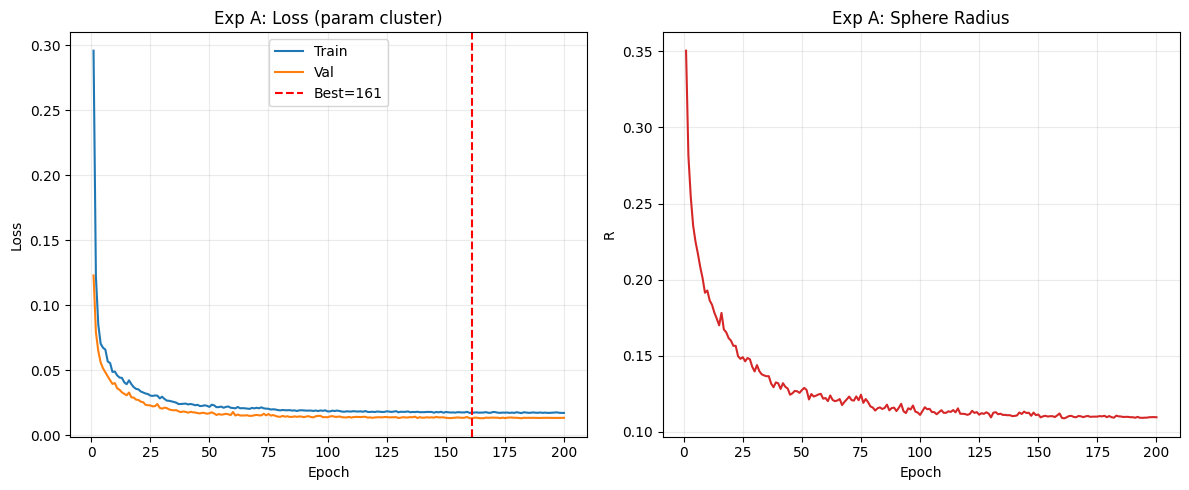

In [7]:
# Exp A 训练曲线
h_a = trainer_a.get_history_df()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(h_a['epoch'], h_a['train_loss'], label='Train')
axes[0].plot(h_a['epoch'], h_a['val_loss'], label='Val')
best = h_a.loc[h_a['val_loss'].idxmin(), 'epoch']
axes[0].axvline(best, color='red', linestyle='--', label=f'Best={best}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Exp A: Loss (param cluster)')
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(h_a['epoch'], h_a['R'], color='tab:red')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('R')
axes[1].set_title('Exp A: Sphere Radius')
axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

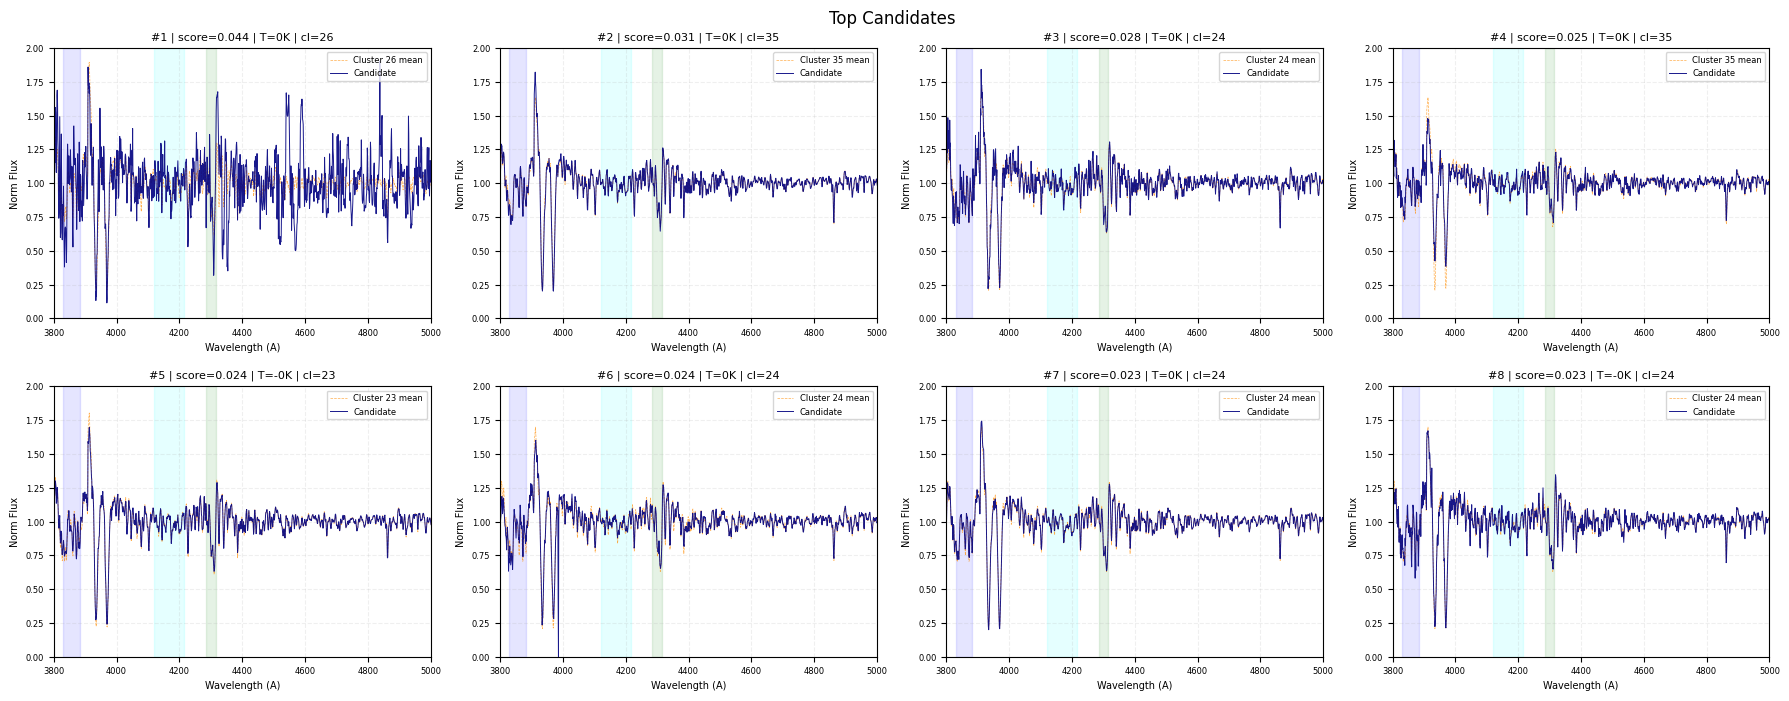

In [8]:
# Exp A 候选光谱可视化（聚类平均作为参考）
cand_a = select_candidates(metrics_a, top_n=12, output_csv='Deep/candidates_v3_param.csv')

TOP_N = 8
cand_viz_a = cand_a.head(TOP_N)
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, (_, row) in enumerate(cand_viz_a.iterrows()):
    ax = axes[i]
    idx = row.name
    cid = int(cluster_labels_a[idx])
    cl_mean = cluster_mean_a[cid]

    # 分子带 + 辅助证认线
    ax.axvspan(3830, 3883, alpha=0.10, color='blue', zorder=0)
    ax.axvspan(4120, 4216, alpha=0.10, color='cyan', zorder=0)
    ax.axvspan(4285, 4315, alpha=0.10, color='green', zorder=0)
    ax.axvspan(5160, 5190, alpha=0.08, color='orange', zorder=0)
    ax.axvspan(8480, 8670, alpha=0.08, color='purple', zorder=0)

    ax.plot(dataset_full.wave, cl_mean, color='darkorange', linewidth=0.5,
            linestyle='--', alpha=0.7, label=f'Cluster {cid} mean')

    if idx < len(dataset_full.X):
        ax.plot(dataset_full.wave, dataset_full.X[idx], color='navy', linewidth=0.7,
                alpha=0.9, label='Candidate')

    score = row.get('anomaly_score', np.nan)
    teff = row.get('teff', np.nan)
    ax.set_title(f'#{i+1} | score={score:.3f} | T={teff:.0f}K | cl={cid}', fontsize=8)
    ax.set_xlabel('Wavelength (A)', fontsize=7)
    ax.set_ylabel('Norm Flux', fontsize=7)
    ax.set_ylim(0, 2)
    ax.set_xlim(3800, 5000)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.2, linestyle='--')
    ax.legend(fontsize=6, loc='upper right')

for j in range(TOP_N, 8):
    axes[j].axis('off')

fig.suptitle('Top Candidates ', fontsize=12, y=0.995)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

---
## Experiment B: 掩带聚类（掩盖 CN/CH 分子带）

将 CN3839/CN4142/CH4300 三个分子带区域用中值填充后，
对掩盖光谱做 PCA 降维 + KMeans 聚类。
这样聚类不受 CN 增强影响，簇内比较更公平。

In [9]:
print('Computing masked-cluster features...')
result_b = compute_physics_features_masked_cluster(dataset_full, random_seed=42)
dataset_b = result_b['dataset']
cluster_labels_b = result_b['cluster_labels']
cluster_mean_b = result_b['cluster_mean_spectra']
print(f'  Features: {dataset_b.X.shape}')
print(f'  Clusters: {result_b["n_clusters"]}')

Computing masked-cluster features...
  Masked-cluster: 45 clusters (PCA-25 on masked spectra)
  Features: (33512, 12)
  Clusters: 45


In [10]:
# Exp B 训练
print('='*60)
print('EXP B: Masked-Band Cluster')
print('='*60)

config_b = DeepSVDDConfig(
    input_dim=dataset_b.n_features,
    hidden_dims=[64, 32],
    latent_dim=8,
    encoder_type='mlp',
    objective='soft-boundary',
    nu=0.05,
    learning_rate=1e-3,
    batch_size=256,
    n_epochs=200,
    early_stopping_patience=40,
    clean_cn_percentile=95.0,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)
print(f'Input: {config_b.input_dim} features')

trainer_b = DeepSVDDTrainer(config_b, save_dir='Deep/checkpoints/v3_masked')
model_b = trainer_b.train(dataset_b, verbose=True)

metrics_b = evaluate_model(model_b, dataset_b, device=config_b.device)
print(summarize_results(metrics_b))

EXP B: Masked-Band Cluster
Input: 12 features
CN pre-clean: threshold=0.0000, removed 0 unlabeled (0.0%), known-CN median=0.0000
  Train samples (clean): 30,096 / 33,439 unlabeled
Model: 3,073 parameters
  Input: 12
  Hidden: [64, 32]
  Latent: 8
  Encoder: mlp
  Objective: soft-boundary
Initializing hypersphere center...

Training for up to 200 epochs...
  Train samples: 30096
------------------------------------------------------------
Epoch  10/200 | loss: 0.0507 | val_loss: 0.0410 | lr: 1.00e-03 *
Epoch  20/200 | loss: 0.0385 | val_loss: 0.0294 | lr: 1.00e-03 *
Epoch  30/200 | loss: 0.0317 | val_loss: 0.0233 | lr: 1.00e-03 *
Epoch  40/200 | loss: 0.0278 | val_loss: 0.0209 | lr: 1.00e-03 *
Epoch  50/200 | loss: 0.0258 | val_loss: 0.0200 | lr: 1.00e-03
Epoch  60/200 | loss: 0.0256 | val_loss: 0.0201 | lr: 1.00e-03
Epoch  70/200 | loss: 0.0254 | val_loss: 0.0191 | lr: 1.00e-03
Epoch  80/200 | loss: 0.0230 | val_loss: 0.0184 | lr: 5.00e-04
Epoch  90/200 | loss: 0.0230 | val_loss: 0.018

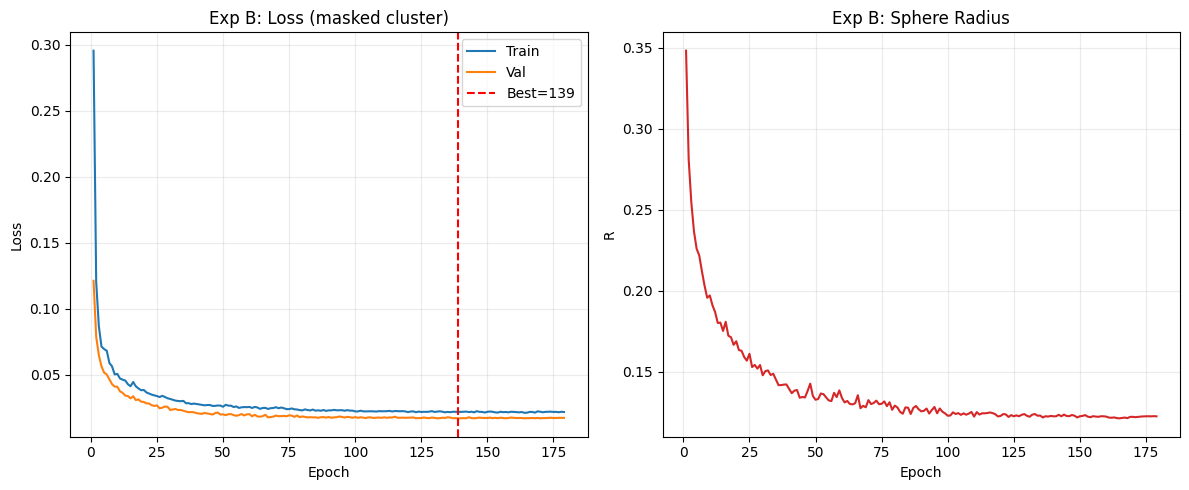

In [11]:
# Exp B 训练曲线
h_b = trainer_b.get_history_df()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(h_b['epoch'], h_b['train_loss'], label='Train')
axes[0].plot(h_b['epoch'], h_b['val_loss'], label='Val')
best = h_b.loc[h_b['val_loss'].idxmin(), 'epoch']
axes[0].axvline(best, color='red', linestyle='--', label=f'Best={best}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Exp B: Loss (masked cluster)')
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(h_b['epoch'], h_b['R'], color='tab:red')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('R')
axes[1].set_title('Exp B: Sphere Radius')
axes[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

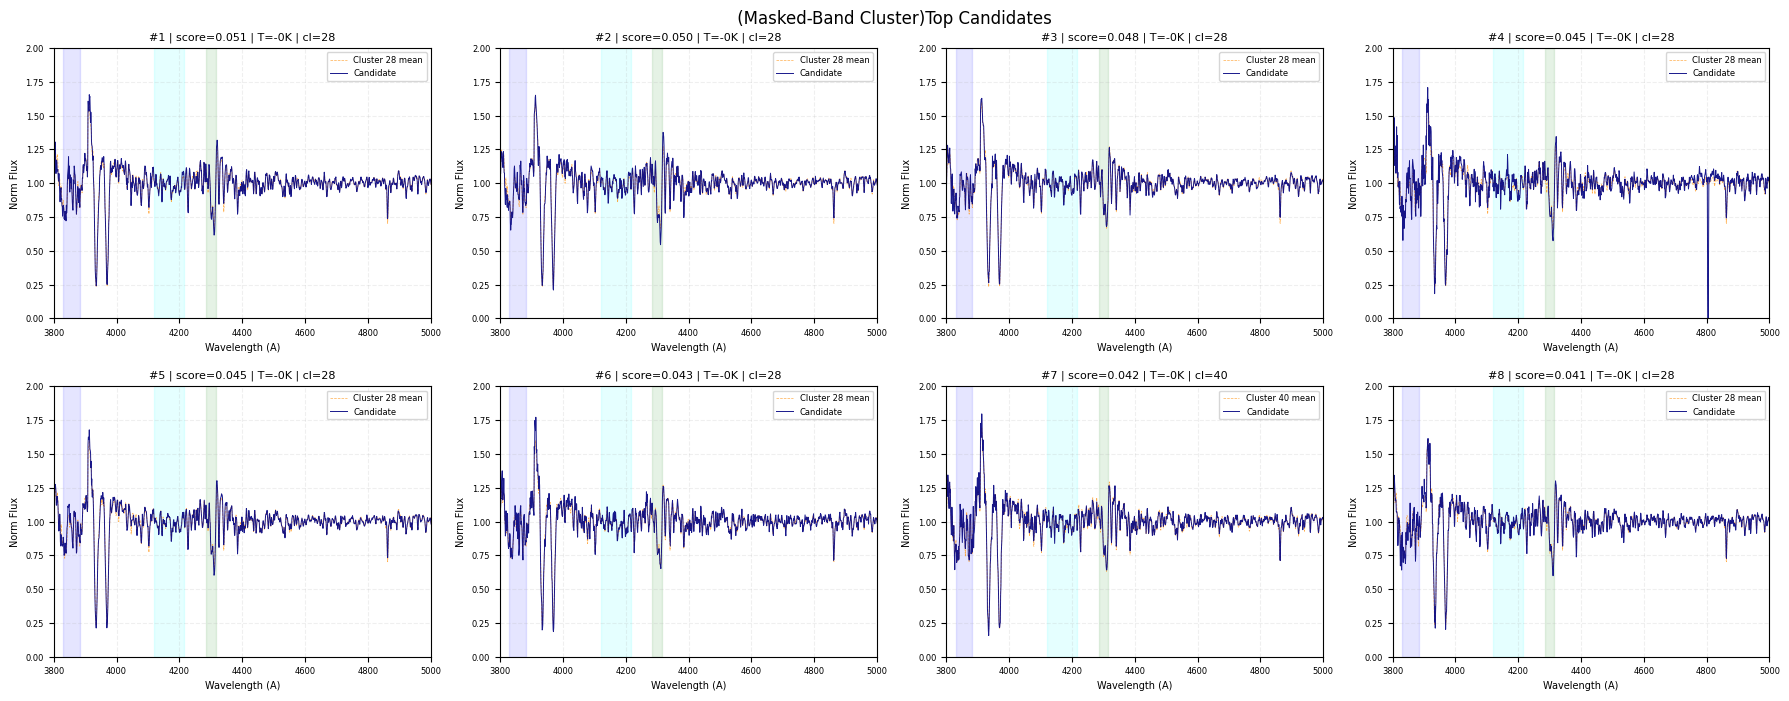

In [12]:
# Exp B 候选光谱可视化（聚类平均作为参考）
cand_b = select_candidates(metrics_b, top_n=12, output_csv='Deep/candidates_v3_masked.csv')

TOP_N = 8
cand_viz_b = cand_b.head(TOP_N)
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, (_, row) in enumerate(cand_viz_b.iterrows()):
    ax = axes[i]
    idx = row.name
    cid = int(cluster_labels_b[idx])
    cl_mean = cluster_mean_b[cid]

    ax.axvspan(3830, 3883, alpha=0.10, color='blue', zorder=0)
    ax.axvspan(4120, 4216, alpha=0.10, color='cyan', zorder=0)
    ax.axvspan(4285, 4315, alpha=0.10, color='green', zorder=0)
    ax.axvspan(5160, 5190, alpha=0.08, color='orange', zorder=0)
    ax.axvspan(8480, 8670, alpha=0.08, color='purple', zorder=0)

    ax.plot(dataset_full.wave, cl_mean, color='darkorange', linewidth=0.5,
            linestyle='--', alpha=0.7, label=f'Cluster {cid} mean')

    if idx < len(dataset_full.X):
        ax.plot(dataset_full.wave, dataset_full.X[idx], color='navy', linewidth=0.7,
                alpha=0.9, label='Candidate')

    score = row.get('anomaly_score', np.nan)
    teff = row.get('teff', np.nan)
    ax.set_title(f'#{i+1} | score={score:.3f} | T={teff:.0f}K | cl={cid}', fontsize=8)
    ax.set_xlabel('Wavelength (A)', fontsize=7)
    ax.set_ylabel('Norm Flux', fontsize=7)
    ax.set_ylim(0, 2)
    ax.set_xlim(3800, 5000)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.2, linestyle='--')
    ax.legend(fontsize=6, loc='upper right')

for j in range(TOP_N, 8):
    axes[j].axis('off')

fig.suptitle(' (Masked-Band Cluster)Top Candidates ', fontsize=12, y=0.995)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

---
## 对比总结

In [ ]:
comparison = pd.DataFrame({
    'Experiment': ['Exp A: Param cluster (teff/logg/feh)',
                   'Exp B: Masked-band cluster'],
    'Clusters': [result_a['n_clusters'], result_b['n_clusters']],
    'AUROC': [metrics_a['auroc'], metrics_b['auroc']],
    'AUPRC': [metrics_a['auprc'], metrics_b['auprc']],
    'precision@50': [metrics_a['precision@50'], metrics_b['precision@50']],
    'precision@100': [metrics_a['precision@100'], metrics_b['precision@100']],
    'precision@200': [metrics_a['precision@200'], metrics_b['precision@200']],
    'Median CN rank': [metrics_a['median_rank_pct'], metrics_b['median_rank_pct']],
})
print('\n' + '='*60)
print('CLUSTERING STRATEGY COMPARISON')
print('='*60)
display(comparison.round(4))


CLUSTERING STRATEGY COMPARISON


,Experiment,Clusters,AUROC,AUPRC,precision@50,precision@100,precision@200,Median CN rank
0,Exp A: Param cluster (teff/logg/feh),45,0.4366,0.0018,0.0,0.00,0.00,0.5016
1,Exp B: Masked-band cluster,45,0.5925,0.0068,0.0,0.02,0.02,0.3469


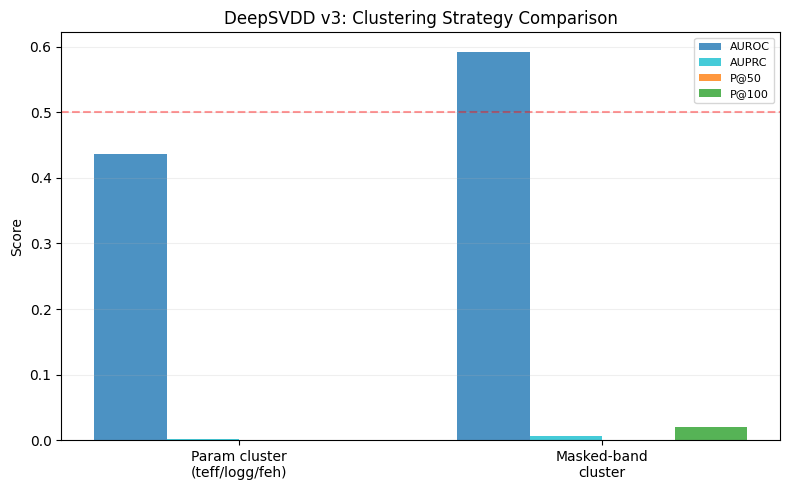

In [ ]:
# 柱状图对比
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
w = 0.2
ax.bar(x - 1.5*w, comparison['AUROC'], w, color='tab:blue', alpha=0.8, label='AUROC')
ax.bar(x - 0.5*w, comparison['AUPRC'], w, color='tab:cyan', alpha=0.8, label='AUPRC')
ax.bar(x + 0.5*w, comparison['precision@50'], w, color='tab:orange', alpha=0.8, label='P@50')
ax.bar(x + 1.5*w, comparison['precision@100'], w, color='tab:green', alpha=0.8, label='P@100')
ax.set_xticks(x)
ax.set_xticklabels(['Param cluster\n(teff/logg/feh)', 'Masked-band\ncluster'])
ax.set_ylabel('Score')
ax.set_title('DeepSVDD v3: Clustering Strategy Comparison')
ax.legend(fontsize=8)
ax.grid(alpha=0.2, axis='y')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

In [ ]:
# 已知 CN 星在两种策略下的 delta 特征对比
meta_a = dataset_a.meta
meta_b = dataset_b.meta
cn_mask = dataset_full.y == 1

print('Delta feature comparison (known CN stars only):')
for feat in ['delta_CN3839', 'delta_CN4142', 'delta_CH4300']:
    a_vals = meta_a.loc[cn_mask, feat].values
    b_vals = meta_b.loc[cn_mask, feat].values
    print(f'  {feat}: param_cluster={np.mean(a_vals):.4f}, masked_cluster={np.mean(b_vals):.4f}')

Delta feature comparison (known CN stars only):
  delta_CN3839: param_cluster=3.1445, masked_cluster=2.2021
  delta_CN4142: param_cluster=1.2144, masked_cluster=1.0219
  delta_CH4300: param_cluster=0.4004, masked_cluster=-0.0342
